# Labwork 6: Map

In [1]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

In [2]:
inputImage = plt.imread("/content/images.jpg")
imageHeight, imageWidth = inputImage.shape[:2]

print("Image shape:", inputImage.shape)

blockSize = (16, 16)
gridSize = (math.ceil(imageWidth / 16), math.ceil(imageHeight / 16))

devInput = cuda.to_device(inputImage)

Image shape: (750, 1200, 3)


## 0. Grayscale

Binarization needs a gray image, so we first convert the image to gray.

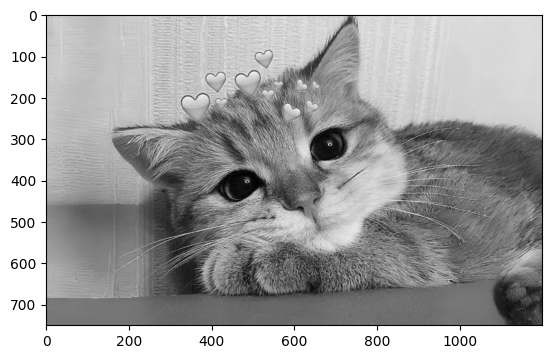

In [3]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidy < src.shape[0] and tidx < src.shape[1]:
        r = src[tidy, tidx, 0]
        g = src[tidy, tidx, 1]
        b = src[tidy, tidx, 2]
        dst[tidy, tidx] = np.uint8((r + g + b) / 3)


devGray = cuda.device_array((imageHeight, imageWidth), np.uint8)
grayscale[gridSize, blockSize](devInput, devGray)
grayImage = devGray.copy_to_host()

plt.imshow(grayImage, cmap="gray")
plt.show()

## 6a. Binarization

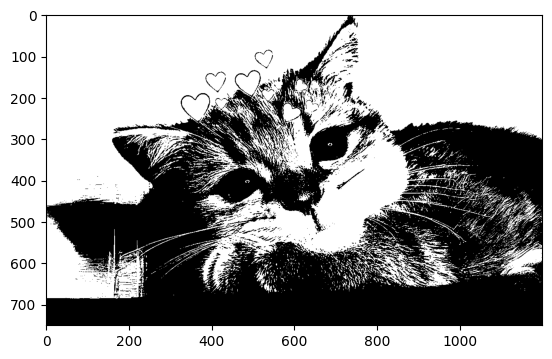

In [4]:
@cuda.jit
def binarize(src, dst, threshold):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidy < src.shape[0] and tidx < src.shape[1]:
        if src[tidy, tidx] < threshold:
            dst[tidy, tidx] = 0
        else:
            dst[tidy, tidx] = 255


threshold = 128

devBinary = cuda.device_array((imageHeight, imageWidth), np.uint8)
binarize[gridSize, blockSize](devGray, devBinary, threshold)
binaryImage = devBinary.copy_to_host()

plt.imsave("binary.png", binaryImage, cmap="gray")
plt.imshow(binaryImage, cmap="gray")
plt.show()

## 6b. Brightness control

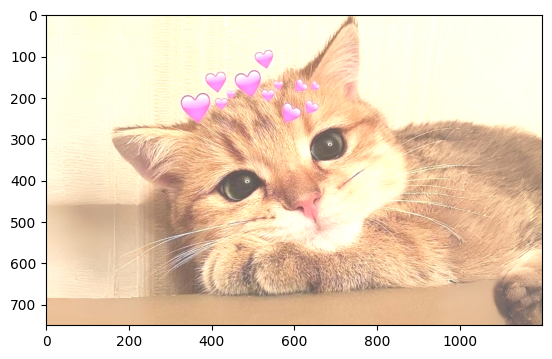

In [5]:
@cuda.jit
def brightness(src, dst, value):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidy < src.shape[0] and tidx < src.shape[1]:
        for ch in range(3):
            v = src[tidy, tidx, ch] + value
            if v > 255:
                v = 255
            if v < 0:
                v = 0
            dst[tidy, tidx, ch] = v


value = 80

devBright = cuda.device_array((imageHeight, imageWidth, 3), np.uint8)
brightness[gridSize, blockSize](devInput, devBright, value)
brightImage = devBright.copy_to_host()

plt.imsave("bright.png", brightImage)
plt.imshow(brightImage)
plt.show()

## 6c. Blending two images

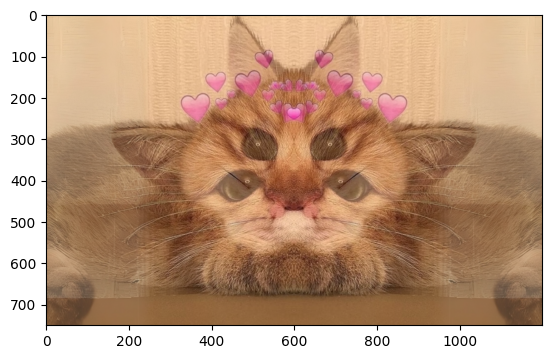

In [6]:
@cuda.jit
def blend(src1, src2, dst, c):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidy < src1.shape[0] and tidx < src1.shape[1]:
        for ch in range(3):
            p1 = src1[tidy, tidx, ch]
            p2 = src2[tidy, tidx, ch]
            dst[tidy, tidx, ch] = np.uint8(c * p1 + (1 - c) * p2)


secondImage = np.fliplr(inputImage).copy()
c = 0.5

devSecond = cuda.to_device(secondImage)
devBlend = cuda.device_array((imageHeight, imageWidth, 3), np.uint8)
blend[gridSize, blockSize](devInput, devSecond, devBlend, c)
blendImage = devBlend.copy_to_host()

plt.imsave("blend.png", blendImage)
plt.imshow(blendImage)
plt.show()

## Block size experiment

4 x 4 | binarize: 0.1795816421508789 ms | brightness: 0.16196250915527344 ms | blend: 0.7160282135009766 ms
8 x 8 | binarize: 0.044035911560058594 ms | brightness: 0.08978843688964844 ms | blend: 0.3623676300048828 ms
16 x 16 | binarize: 0.037899017333984375 ms | brightness: 0.06472110748291016 ms | blend: 0.3603029251098633 ms
32 x 32 | binarize: 0.04225730895996094 ms | brightness: 0.07715702056884766 ms | blend: 0.39711475372314453 ms


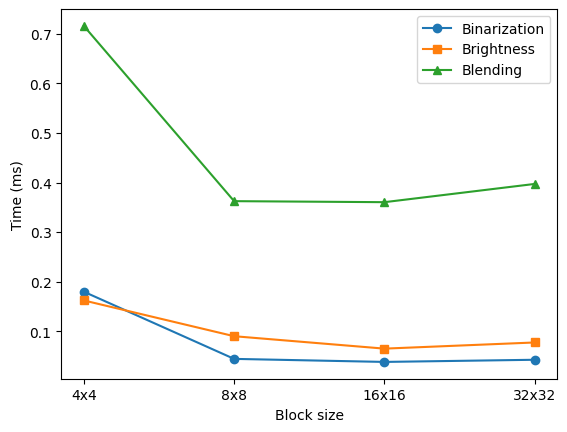

In [7]:
sizes = [4, 8, 16, 32]
timesBinary = []
timesBright = []
timesBlend = []

for s in sizes:
    blockSize = (s, s)
    gridSize = (math.ceil(imageWidth / s), math.ceil(imageHeight / s))

    start = time.time()
    for _ in range(50):
        binarize[gridSize, blockSize](devGray, devBinary, threshold)
    cuda.synchronize()
    timesBinary.append((time.time() - start) / 50 * 1000)

    start = time.time()
    for _ in range(50):
        brightness[gridSize, blockSize](devInput, devBright, value)
    cuda.synchronize()
    timesBright.append((time.time() - start) / 50 * 1000)

    start = time.time()
    for _ in range(50):
        blend[gridSize, blockSize](devInput, devSecond, devBlend, c)
    cuda.synchronize()
    timesBlend.append((time.time() - start) / 50 * 1000)

    print(s, "x", s, "| binarize:", timesBinary[-1], "ms | brightness:", timesBright[-1],
          "ms | blend:", timesBlend[-1], "ms")

labels = [f"{s}x{s}" for s in sizes]
plt.plot(labels, timesBinary, marker="o", label="Binarization")
plt.plot(labels, timesBright, marker="s", label="Brightness")
plt.plot(labels, timesBlend, marker="^", label="Blending")
plt.xlabel("Block size")
plt.ylabel("Time (ms)")
plt.legend()
plt.savefig("blocksize_vs_time.png")
plt.show()